The `ModApte' train/test split of the Reuters 21578
Distribution 1.0 data set consists of 12902 Reuters
newswire articles in 135 overlapping topic categories.
Following several other studies (Joachims 1998; Liere
and Tadepalli 1997) we build binary classiers for each
of the 10 most populous classes. We ignore words on
a stoplist, but do not use stemming. The resulting vocabulary
has 19371 words.

For Reuters, results on the Mod-Apte test set are
shown as precision-recall breakeven points, a standard
information retrieval measure for binary classication.
Recall and Precision are dened as:

Recall =
number of of correct positive predictions/number of positive examples(9)


Precision =
number of correct positive predictions/ number of positive predictions(10)


The precision-recall breakeven point is the value at which precision and recall are equal






In [64]:
from pathlib import Path
import pandas as pd
from reuters import iter_sgm_files
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.feature_extraction.text import CountVectorizer

In [2]:
nltk.download('stopwords')
nltk.download('punkt_tab')
print(stopwords.words('english')[:5])

['a', 'about', 'above', 'after', 'again']


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ynieu\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ynieu\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [3]:
SRC_FOLDER = Path('reuters/')
df = pd.DataFrame(iter_sgm_files(SRC_FOLDER))

# 1. Describing data

You might think properties like the source of the corpus, number of documents, number of classes, using train/test split or cross-validation, any filtering applied.

In [4]:
# algemene informatie
print(df.columns, 'zijn de kolommen')
df['topics'].unique()
print(f'the length of the dataframe is {len(df)} rows')
print(f'{df['topics_present'].unique()}: means that every row has a topic')
print(f'{df['lewissplit'].unique()}: means that df is split in test and train')

# informatie over train test data
train = df[df['lewissplit'] == 'TRAIN']
percentage_train = len(train)/len(df)
test = df[df['lewissplit'] == 'TEST']
percentage_test = len(test)/len(df)
print(percentage_test, 'percentage test')
print(percentage_train, 'percentage train')

# informatie over de onderwerpen
topics_list = df['topics'].str.split(',')   # split strings naar lists
all_topics = topics_list.explode()          # maak elke topic een aparte rij
all_topics = (
    df['topics']
    .str.split(',')
    .explode()
    .dropna()
)
all_topics = all_topics[all_topics != '']
unique_topics = all_topics.unique().tolist()  # unieke topics naar list
print('de onderwerpen zijn:', unique_topics)
print('aantal klassen:', len(unique_topics))

topic_counts = all_topics.value_counts()
print(topic_counts.head())


Index(['topics_present', 'lewissplit', 'topics', 'body_text', 'filename',
       'record_ix'],
      dtype='object') zijn de kolommen
the length of the dataframe is 12902 rows
['YES']: means that every row has a topic
['TRAIN' 'TEST']: means that df is split in test and train
0.25569679119516353 percentage test
0.7443032088048365 percentage train
de onderwerpen zijn: ['cocoa', 'grain', 'wheat', 'corn', 'barley', 'oat', 'sorghum', 'veg-oil', 'linseed', 'lin-oil', 'soy-oil', 'sun-oil', 'soybean', 'oilseed', 'sunseed', 'earn', 'acq', 'copper', 'housing', 'money-supply', 'coffee', 'ship', 'sugar', 'trade', 'reserves', 'meal-feed', 'soy-meal', 'rye', 'cotton', 'carcass', 'livestock', 'crude', 'nat-gas', 'cpi', 'gnp', 'money-fx', 'interest', 'bop', 'rice', 'red-bean', 'rubber', 'copra-cake', 'palm-oil', 'palmkernel', 'tea', 'plywood', 'alum', 'gold', 'platinum', 'strategic-metal', 'tapioca', 'tin', 'rapeseed', 'groundnut-oil', 'rape-oil', 'cornglutenfeed', 'citruspulp', 'rape-meal', 'wool', 

<Axes: xlabel='topics'>

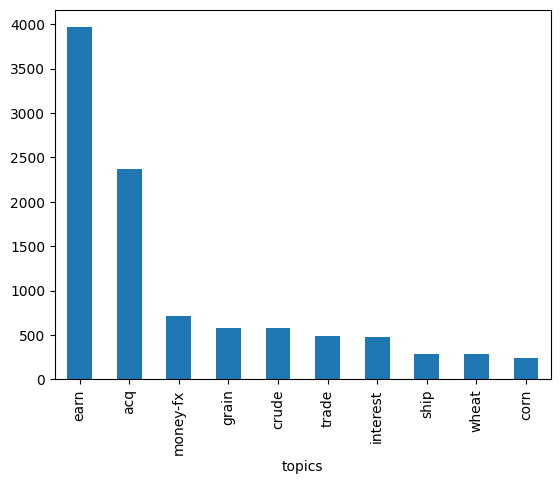

In [5]:
topic_counts.head(10).plot(kind='bar')

In [6]:
df['text_length'] = df['body_text'].str.len()

print("Average document length:", df['text_length'].mean())
print("Max length:", df['text_length'].max())
print("Min length:", df['text_length'].min())

Average document length: 826.5436241610738
Max length: 13395.0
Min length: 55.0


In [7]:
df['num_topics'] = df['topics'].str.split(',').str.len()
print(df['num_topics'].value_counts())
# Some documents belong to multiple topics, making this a multi-label classification problem.

num_topics
1     11241
2      1199
3       255
4        94
5        53
6        27
7        11
8         6
9         6
10        4
12        2
14        2
16        1
11        1
Name: count, dtype: int64


## 2. Description of pre-processing

Describe the steps taking in converting the raw documents into tokens, like tokenization, lowercasing, stop-word removal, stemming or lemmatization, vocabulary size, handling of rare words.

In [46]:
# Study: 
# We ignore words on a stoplist, but do not use stemming. The resulting vocabulary has 19371 words.

def tokenize_text(text):
    # check lege of niet-string
    if not isinstance(text, str):
        return []

    # verwijder leestekens
    text = "".join([c for c in text if c not in string.punctuation])

    # lowercase
    text = text.lower()

    # tokenize
    tokens = word_tokenize(text)

    # stopwoorden verwijderen
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]

    # verwijder tokens die volledig uit cijfers bestaan
    tokens = [word for word in tokens if not word.isdigit()]

    # verwijder hele korte tokens (bijv. lengte 1)
    tokens = [word for word in tokens if len(word) > 1]

    return tokens


df = df[df["body_text"].notna()]
train_df = df[df['lewissplit'] == 'TRAIN']
test_df = df[df['lewissplit'] == 'TEST']

# tokens genereren per document
train_df["tokens"] = train_df["body_text"].apply(tokenize_text)
test_df["tokens"] = test_df["body_text"].apply(tokenize_text)


C:\Users\ynieu\AppData\Local\Temp\ipykernel_21180\1141604951.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df["tokens"] = train_df["body_text"].apply(tokenize_text)
C:\Users\ynieu\AppData\Local\Temp\ipykernel_21180\1141604951.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df["tokens"] = test_df["body_text"].apply(tokenize_text)


In [ ]:
all_tokens = [token for doc in train_df["tokens"] for token in doc]
freq = Counter(all_tokens)
filtered_tokens_set = {word for word, count in freq.items() if count > 1}

# Filter de tokens
train_df["tokens"] = train_df["tokens"].apply(lambda doc: [w for w in doc if w in filtered_tokens_set])
test_df["tokens"] = test_df["tokens"].apply(lambda doc: [w for w in doc if w in filtered_tokens_set])
vocab = sorted(filtered_tokens_set)
print(f"Vocabulary size: {len(vocab)}")

Vocabulary size: 17594


C:\Users\ynieu\AppData\Local\Temp\ipykernel_21180\479601488.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df["tokens"] = train_df["tokens"].apply(lambda doc: [w for w in doc if w in filtered_tokens_set])
C:\Users\ynieu\AppData\Local\Temp\ipykernel_21180\479601488.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df["tokens"] = test_df["tokens"].apply(lambda doc: [w for w in doc if w in filtered_tokens_set])


## 3. Feature Engineering

Describe the conversion of the pre-processed text into numerical representations

In [ ]:
text_for_vectorizing_train = train_df["tokens"].apply(lambda x: " ".join(x))
text_for_vectorizing_test = test_df["tokens"].apply(lambda x: " ".join(x))

vectorizer = CountVectorizer(vocabulary=vocab)  # gebruik CountVectorizer zoals in de paper
X_train = vectorizer.fit_transform(text_for_vectorizing_train)
X_test = vectorizer.transform(text_for_vectorizing_test)

print(f"Vorm van de training feature matrix: {X_train.shape}")
print(f"Vorm van de test feature matrix: {X_test.shape}")

all_topics = []
for sublist in train_df["topics"].dropna():
    for t in sublist.split(','):
        t = t.strip()
        if t != '':
            all_topics.append(t)

topic_counts = Counter(all_topics)
top10_topics = [topic for topic, count in topic_counts.most_common(10)]
print("Top 10 topics:", top10_topics)



Vorm van de training feature matrix: (8762, 17594)
Vorm van de test feature matrix: (3009, 17594)
Top 10 topics: ['earn', 'acq', 'money-fx', 'grain', 'crude', 'trade', 'interest', 'wheat', 'ship', 'corn']


## 4. Model specification

Description of the model, name model assumptions, model hyperparameters available, smoothing methods available.

In [67]:
models = {}       
y_test_dict = {} 

for topic in top10_topics:
    # Binaire labels per topic
    y_train_topic = train_df["topics"].apply(lambda t: 1 if topic in str(t).split(',') else 0)
    y_test_topic = test_df["topics"].apply(lambda t: 1 if topic in str(t).split(',') else 0)
    
    # Multinomial Naive Bayes
    model_mnb = MultinomialNB(alpha=1.0)
    model_mnb.fit(X_train, y_train_topic)
    
    # Bernoulli Naive Bayes
    model_bnb = BernoulliNB()
    model_bnb.fit(X_train, y_train_topic)
    
    # Beide modellen opslaan in een nested dictionary per topic
    models[topic] = {
        "MultinomialNB": model_mnb,
        "BernoulliNB": model_bnb
    }
    
    # Testlabels opslaan
    y_test_dict[topic] = y_test_topic


## 5. Training phase

## 6. Evaluation

## 7. Results